# Negative-data demo — twin-pair desync (`put_mouse_on_pad`)

Each episode is a **matched twin**. The scripted CuRobo planner commits to a plan against the
**virtual** scene it sees, while we apply **exactly one controlled edit to the physical scene it
cannot see**. Because the only difference between twins is that single known edit, **every failure
is causally labeled by construction** — no human annotation, no learned classifier.

| Scene | Case | Edit (physical only) | Trigger | Expected outcome |
|---|---|---|---|---|
| `clean` | `baseline` | none | — | `clean_success` |
| `clean` | `shift_object` | grasp target moved **after** grasp pose is locked | `after_grasp_plan` | `plan_aborted` / empty grasp |
| `clean` | `shift_target` | placement destination moved after its pose is read | `immediate` | `wrong_place_pose` |
| `d6/d10/d15` | `baseline` | none | — | `clean_success` |
| `d6/d10/d15` | `shift_obstacle` | obstacle slid onto the grasp→place corridor | `immediate` | `success_with_collision` |

Object/target shifts run **clean-only**; obstacle shifts run **cluttered-only** (the scene-pairing
rule that avoids confounding attribution). Magnitudes are **forced** so each failure is unambiguous.

**Per episode we show three things** (all derived offline from the recorded labels & raw per-frame
state — same `targeted.py` the HTML viewer uses):

- **WHAT** — the symptom flag-set read from sim (`grasp_failure`, `placement_failure`, `collision`, `planning_failure`).
- **WHY** — the cause, known by construction from the edit we applied.
- **quality** — <span style="color:#2e7d32;font-weight:700">good</span> (clean success) ·
  <span style="color:#f9a825;font-weight:700">suboptimal</span> (succeeded but something happened, e.g. a brush) ·
  <span style="color:#c62828;font-weight:700">bad</span> (failed).

Under each twin pair, two synced curves: **task progress** 0–100% (object→destination) and
**safety** 0–1 (1 = clear; dips as an end-effector nears non-target objects or moves fast; ● marks contact frames).

> **Viewing vs. running.** Outputs are pre-baked, so this notebook renders fully without a kernel.
> To re-run it (`Run All`) you need this repo present and the `robopro` env with a kernel
> (`pip install ipykernel`); cells read the episodes from `negative_data_demo/`
> live. Override the location with the `NEG_DEMO_ROOT` env var.


## Self-running

This notebook **produces its own artifacts**. The **Collect** cell below runs the twin-pair demo —
spawning one *isolated* `run_targeted_episode.py` subprocess per episode (so CuRobo warm-start state
never leaks between baseline and perturbed twins) across the free GPUs — writing episodes + videos
into a `negative_data_demo/` directory next to this notebook. The remaining cells load those
artifacts and render the table, tallies, twin videos, and progress/safety curves.

- **Outputs are pre-baked**, so the notebook also renders on open with no kernel.
- **To re-run:** open it in the consolidated uv env (`policy/pi05/.venv`, has `ipykernel`) and `Run All`.
  Tune `COLLECT`, `SEEDS_PER_SCENE`, `DENSITIES`, `GPUS` in the **Configuration** cell (the committed
  default is a reduced run: `clean` + `d6`, 1 seed each).


In [1]:
# === Configuration ===
import os
import sys
from pathlib import Path


def _find_repo_root():
    """Repo root = the ancestor holding both customized_robotwin/ and benchmark/."""
    for base in [Path.cwd(), *Path.cwd().parents]:
        if (base / "customized_robotwin").is_dir() and (base / "benchmark").is_dir():
            return base
    raise FileNotFoundError("run this notebook from inside the RoboPRO repo checkout")


REPO_ROOT = _find_repo_root()
OUT_ROOT = REPO_ROOT / "negative_data_demo"          # artifacts produced by THIS notebook
RUN_EPISODE = REPO_ROOT / "run_targeted_episode.py"

# --- what to collect (tune freely; committed default = reduced run) ---
COLLECT = True            # False -> skip collection, just render whatever is already in OUT_ROOT
SEEDS_PER_SCENE = 1       # qualified seeds per scene
DENSITIES = [6]           # cluttered densities for the obstacle case, e.g. [6, 10, 15]
GPUS = None               # None = auto-detect free GPUs (>= GPU_MIN_FREE_GIB); or e.g. ["4", "5"]
CANDIDATE_SEEDS = list(range(0, 6))
TIMEOUT = 1200            # per-episode seconds
GPU_MIN_FREE_GIB = 15.0

TASK, SUBDIR, CLEAN_CONFIG = "put_mouse_on_pad", "office", "bench_demo_office_clean"
# Forced perturbation params (curated for a clear, on-video failure).
SHIFT_OBJECT_PARAMS = {"target_class": "lateral", "magnitude_cm": 4.5, "sign": 1,
                       "magnitude_bin_index": 3, "magnitude_bin_cm": [3.5, 5.0], "mixed_angle_deg": 0.0}
SHIFT_TARGET_PARAMS = {"target_class": "lateral", "magnitude_cm": 3.5, "sign": 1,
                       "magnitude_bin_index": 2, "magnitude_bin_cm": [2.5, 3.5], "mixed_angle_deg": 0.0}
SHIFT_OBSTACLE_PARAMS = {"mode": "corridor", "corridor_t": 0.55}

print(f"REPO_ROOT = {REPO_ROOT}")
print(f"OUT_ROOT  = {OUT_ROOT}")
print(f"COLLECT={COLLECT}  seeds/scene={SEEDS_PER_SCENE}  densities={DENSITIES}  gpus={GPUS or 'auto'}")


REPO_ROOT = /work/mohammed/EAI_RSM/RoboPRO
OUT_ROOT  = /work/mohammed/EAI_RSM/RoboPRO/negative_data_demo
COLLECT=True  seeds/scene=1  densities=[6]  gpus=auto


In [2]:
# === Collect: run the twin-pair demo (this folds in the former make_negative_data_demo.py) ===
# Each (scene, seed) chain holds ONE GPU and runs its ordered cases; chains run concurrently across
# the GPU pool. Every episode is a SEPARATE subprocess (run_targeted_episode.py) so CuRobo warm-start
# state never leaks between the baseline and perturbed twins. A scene keeps drawing candidate seeds
# until SEEDS_PER_SCENE of them qualify (baseline = clean_success; cluttered also needs an eligible
# corridor obstacle). Magnitudes are FORCED so each failure is unambiguous on video.
import json
import queue
import shutil
import subprocess
import time
from concurrent.futures import FIRST_COMPLETED, ThreadPoolExecutor, wait


def build_scenes(densities):
    scenes = [{"key": "clean", "config": CLEAN_CONFIG, "kind": "clean", "require_obstacle": False,
               "cases": [("baseline", "baseline", "none", None),
                         ("shift_object", "perturbed", "shift_object", SHIFT_OBJECT_PARAMS),
                         ("shift_target", "perturbed", "shift_target", SHIFT_TARGET_PARAMS)]}]
    for d in densities:
        scenes.append({"key": f"d{d}", "config": f"bench_demo_office_d{d}", "kind": "cluttered",
                       "require_obstacle": True,
                       "cases": [("baseline", "baseline", "none", None),
                                 ("shift_obstacle", "perturbed", "shift_obstacle", SHIFT_OBSTACLE_PARAMS)]})
    return scenes


def detect_free_gpus(min_free_gib=GPU_MIN_FREE_GIB):
    out = subprocess.check_output(
        ["nvidia-smi", "--query-gpu=index,memory.free", "--format=csv,noheader,nounits"], text=True, timeout=30)
    free = []
    for row in out.strip().splitlines():
        idx, mib = (c.strip() for c in row.split(","))
        if float(mib) / 1024.0 >= min_free_gib:
            free.append(idx)
    return free


def run_episode(config, seed, role, ptype, params, pair_id, out_dir, gpu, timeout):
    cmd = [sys.executable, "-u", str(RUN_EPISODE), "--task-name", TASK, "--task-config", config,
           "--bench-subdir", SUBDIR, "--seed", str(seed), "--role", role, "--ptype", ptype,
           "--out-dir", str(out_dir)]
    if params is not None:
        cmd += ["--params-json", json.dumps(params)]
    if pair_id:
        cmd += ["--pair-id", pair_id]
    env = dict(os.environ)
    env.setdefault("ROBOTWIN_ROOT", str(REPO_ROOT / "customized_robotwin"))
    env.setdefault("BENCH_ROOT", str(REPO_ROOT / "benchmark"))
    env["ROBOTWIN_BENCH_TASK"] = "bench"
    env["PYTHONNOUSERSITE"] = "1"
    env["PYTHONUNBUFFERED"] = "1"
    if gpu is not None:
        env["CUDA_VISIBLE_DEVICES"] = str(gpu)
    out_dir.mkdir(parents=True, exist_ok=True)
    t0 = time.time()
    with open(out_dir / "run.log", "w", encoding="utf-8") as log:
        proc = subprocess.run(cmd, env=env, stdout=log, stderr=subprocess.STDOUT, timeout=timeout, check=False)
    ep = {}
    if (out_dir / "episode.json").exists():
        ep = json.loads((out_dir / "episode.json").read_text(encoding="utf-8"))
    ep["_returncode"] = proc.returncode
    return ep, time.time() - t0


def is_clean_success(ep):
    return bool(ep) and ep.get("status") == "recorded" and ep.get("outcome") == "clean_success"


def run_seed_chain(scene, seed, gpu, out_root, timeout):
    pair = f"{TASK}__{scene['config']}__seed{seed:05d}"
    seed_dir = out_root / scene["key"] / f"seed{seed:05d}"
    results = {}
    for case_key, role, ptype, params in scene["cases"]:
        ep, dt = run_episode(scene["config"], seed, role, ptype, params, pair, seed_dir / case_key, gpu, timeout)
        results[case_key] = ep
        print(f"    [{scene['key']:5s} seed {seed:>2d} gpu {str(gpu):>2s}] {case_key:14s} -> "
              f"{ep.get('status', '?'):20s} {ep.get('outcome') or '-':24s} ({dt:.0f}s)", flush=True)
        if case_key == "baseline" and not is_clean_success(ep):
            return False, results
        if scene["require_obstacle"] and ptype == "shift_obstacle" and ep.get("status") != "recorded":
            return False, results
    return True, results


def schedule(scenes, gpus, out_root, timeout, candidate_seeds, need):
    gpu_pool = queue.Queue()
    for g in gpus:
        gpu_pool.put(g)
    by_key = {s["key"]: s for s in scenes}
    accepted = {s["key"]: [] for s in scenes}
    inflight = {s["key"]: 0 for s in scenes}
    cand = {s["key"]: iter(candidate_seeds) for s in scenes}

    def task(scene_key, seed):
        gpu = gpu_pool.get()
        try:
            return scene_key, seed, run_seed_chain(by_key[scene_key], seed, gpu, out_root, timeout)
        finally:
            gpu_pool.put(gpu)

    ex = ThreadPoolExecutor(max_workers=len(gpus))
    futures = set()

    def try_submit(scene_key):
        if len(accepted[scene_key]) + inflight[scene_key] >= need:
            return
        try:
            seed = next(cand[scene_key])
        except StopIteration:
            return
        inflight[scene_key] += 1
        futures.add(ex.submit(task, scene_key, seed))

    for s in scenes:
        while len(accepted[s["key"]]) + inflight[s["key"]] < need:
            n = inflight[s["key"]]
            try_submit(s["key"])
            if inflight[s["key"]] == n:
                break
    while futures:
        done, futures = wait(futures, return_when=FIRST_COMPLETED)
        futures = set(futures)
        for fut in done:
            scene_key, seed, (qualified, results) = fut.result()
            inflight[scene_key] -= 1
            if qualified and len(accepted[scene_key]) < need:
                accepted[scene_key].append((seed, results))
            else:
                print(f"[demo] {scene_key} seed {seed} not qualified - drawing another", flush=True)
            try_submit(scene_key)
    ex.shutdown()
    return accepted


def collect_video(out_root, scene_key, seed, case_key):
    case_dir = out_root / scene_key / f"seed{seed:05d}" / case_key
    vids = sorted((case_dir / "video").glob("*.mp4")) if (case_dir / "video").is_dir() else []
    if vids:
        dest = out_root / "videos" / f"{scene_key}_seed{seed:05d}_{case_key}.mp4"
        dest.parent.mkdir(parents=True, exist_ok=True)
        shutil.copy2(vids[0], dest)


if COLLECT:
    gpus = GPUS or detect_free_gpus()
    if not gpus:
        raise SystemExit(f"no GPU has >= {GPU_MIN_FREE_GIB:.0f} GiB free (free one or set GPUS)")
    scenes = build_scenes(DENSITIES)
    print(f"[demo] OUT_ROOT={OUT_ROOT}  GPUs={gpus}  scenes={[s['key'] for s in scenes]}  "
          f"seeds/scene={SEEDS_PER_SCENE}", flush=True)
    t0 = time.time()
    accepted = schedule(scenes, gpus, OUT_ROOT, TIMEOUT, CANDIDATE_SEEDS, SEEDS_PER_SCENE)
    for scene in scenes:
        for seed, results in sorted(accepted[scene["key"]]):
            for case_key, _r, _p, _x in scene["cases"]:
                if results.get(case_key):
                    collect_video(OUT_ROOT, scene["key"], seed, case_key)
    print(f"\n[demo] collected in {time.time() - t0:.0f}s; qualified seeds per scene: "
          f"{ {k: [s for s, _ in v] for k, v in accepted.items()} }", flush=True)
else:
    print("[demo] COLLECT=False - skipping collection; rendering existing artifacts in OUT_ROOT")


[demo] OUT_ROOT=/work/mohammed/EAI_RSM/RoboPRO/negative_data_demo  GPUs=['0', '1', '2', '4', '5', '6', '7']  scenes=['clean', 'd6']  seeds/scene=1


    [clean seed  0 gpu  0] baseline       -> recorded             clean_success            (388s)


    [d6    seed  0 gpu  1] baseline       -> recorded             clean_success            (485s)


    [clean seed  0 gpu  0] shift_object   -> recorded             plan_aborted             (225s)


    [d6    seed  0 gpu  1] shift_obstacle -> recorded             success_with_collision   (443s)


    [clean seed  0 gpu  0] shift_target   -> recorded             wrong_place_pose         (410s)



[demo] collected in 1022s; qualified seeds per scene: {'clean': [0], 'd6': [0]}


In [3]:
import base64, io, json, os, sys
import html as _html
from pathlib import Path

import matplotlib
matplotlib.use("Agg")  # we always render figures to PNG explicitly and emit them
import matplotlib.pyplot as plt
import pandas as pd


# --- locate the demo dir + the pure targeted modules (labels/metrics) ---------
def _find_demo_root():
    env = os.environ.get("NEG_DEMO_ROOT")
    if env and Path(env).exists():
        return Path(env).resolve()
    here = Path.cwd().resolve()
    for base in [here, *here.parents]:
        d = base / "customized_robotwin" / "data" / "negative_data_demo"
        if d.exists():
            return d
    for base in [here, *here.parents]:  # maybe cwd is already inside the demo dir
        if (base / "videos").exists() and next(base.rglob("episode.json"), None):
            return base
    raise FileNotFoundError("could not find negative_data_demo; set NEG_DEMO_ROOT")


ROOT = OUT_ROOT  # produced by the Collect cell above
import robo_negative as targeted   # installed package (consolidated negative-data library)
labels = metrics = targeted


# --- display palette (matches visualize_negative_data.py) ---------------------
QUALITY_COLOR = {"good": "#2e7d32", "suboptimal": "#f9a825", "bad": "#c62828", "?": "#607d8b"}
WHAT_COLOR = {"ok": "#2e7d32", "absorbed": "#2e7d32", "grasp_failure": "#c62828",
              "placement_failure": "#ad1457", "collision": "#e65100",
              "planning_failure": "#6a1b9a", "?": "#607d8b"}
ROLE_COLOR = {"baseline": "#1565c0", "perturbed": "#e65100", "?": "#777"}
# Curves are colored/labeled by CASE so the two clean perturbed twins
# (shift_object vs shift_target) are distinguishable, not both "perturbed".
CASE_COLOR = {"baseline": "#1565c0", "shift_object": "#e65100",
              "shift_target": "#6a1b9a", "shift_obstacle": "#e65100", "?": "#777"}
SCENE_ORDER = {"clean": 0, "d6": 1, "d8": 2, "d10": 3, "d12": 4, "d15": 5}
CASE_ORDER = {"baseline": 0, "shift_object": 1, "shift_target": 2, "shift_obstacle": 1}


def scene_key(cfg):
    if not cfg:
        return "?"
    tail = cfg.replace("bench_demo_office_", "")
    return tail if tail.startswith("d") and tail[1:].isdigit() else ("clean" if "clean" in tail else tail)


def derive(ep):
    """WHAT flag-set / WHY / quality + the headline signals for one episode."""
    ann = labels.annotate(ep)
    what = ann["what"] or (["absorbed"] if ann["why"] != "none" else ["ok"])
    cmd = ep.get("commanded") or {}
    ach = ep.get("achieved") or {}
    sig = ep.get("signals") or {}
    cmet = sig.get("collision_metrics") or {}
    return {"what": what, "why": ann["why"], "why_role": ann["why_role"], "axis": ann["why_axis"],
            "magnitude_cm": cmd.get("magnitude_cm"), "achieved_cm": ach.get("achieved_magnitude_cm"),
            "quality": ann["quality"], "task_success": ann["task_success"],
            "object_moved_cm": sig.get("object_moved_cm"), "place_error_cm": sig.get("place_error_cm"),
            "perturbed_actor": ep.get("perturbed_actor"),
            "collision_bodies": cmet.get("robot_to_static_object_names") or [],
            "contact_frames": ann["what_frames"].get("collision", [])}


def load_records(root):
    """One record per episode: annotation + per-frame curves + base64 video."""
    recs = []
    for ej in sorted(Path(root).rglob("episode.json")):
        try:
            ep = json.loads(ej.read_text(encoding="utf-8"))
        except Exception:
            continue
        ep_dir = ej.parent
        vids = sorted((ep_dir / "video").glob("*.mp4")) if (ep_dir / "video").is_dir() else []
        vb64 = base64.b64encode(vids[0].read_bytes()).decode() if vids else None
        curves = {}
        hs = sorted((ep_dir / "data").glob("*.hdf5")) if (ep_dir / "data").is_dir() else []
        st = None
        if hs:
            try:
                st = metrics.load_frame_state(hs[0])
            except Exception:
                st = None
        if st:
            pr = metrics.compute_progress(ep, st)
            if pr:
                curves["p"] = pr["values"]
            sf = metrics.compute_safety(ep, st)
            if sf:
                curves["s"] = sf["values"]
        recs.append({"ep": ep, "d": derive(ep), "curves": curves, "vb64": vb64,
                     "scene": scene_key(ep.get("task_config", "")), "seed": ep.get("scene_seed"),
                     "case": ep.get("perturbation_type") or "baseline",
                     "role": ep.get("pair_role") or "?"})
    return recs


RECORDS = load_records(ROOT)
GROUPS = {}  # scene -> seed -> [record]
for r in RECORDS:
    GROUPS.setdefault(r["scene"], {}).setdefault(r["seed"], []).append(r)
SCENES = sorted(GROUPS, key=lambda s: SCENE_ORDER.get(s, 99))


# --- rendering helpers (return MIME bundles; `show` displays them) ------------
def badge(text, color):
    return (f'<span style="background:{color};color:#fff;padding:2px 8px;border-radius:10px;'
            f'font-size:12px;font-weight:600">{_html.escape(str(text))}</span>')


def num(v, suffix="", n=2):
    return f"{v:.{n}f}{suffix}" if isinstance(v, (int, float)) else "—"


def card_html(r):
    d, ep = r["d"], r["ep"]
    if r["vb64"]:
        vid = (f'<video controls loop muted width="320" preload="metadata">'
               f'<source src="data:video/mp4;base64,{r["vb64"]}" type="video/mp4"></video>')
    else:
        vid = ('<div style="width:320px;height:190px;display:flex;align-items:center;'
               'justify-content:center;background:#eee;color:#888;border-radius:6px">no video</div>')
    title = f'{r["role"]} · ' + (ep.get("perturbation_type") or "no perturbation")
    rows = [("WHAT", " ".join(badge(w, WHAT_COLOR.get(w, "#607d8b")) for w in d["what"])),
            ("WHY", f'{badge(d["why"], "#1565c0")} ' + (
                f'<small style="color:#888">{d["why_role"]} · {d["axis"] or "?"}</small>'
                if d["why"] != "none" else "")),
            ("quality", badge(d["quality"], QUALITY_COLOR.get(d["quality"], "#607d8b"))),
            ("task_success", "✅" if d["task_success"] else ("❌" if d["task_success"] is False else "—"))]
    if d["why"] != "none":
        rows.append(("error magnitude", f'{num(d["magnitude_cm"], " cm")} '
                     f'<small style="color:#888">(achieved {num(d["achieved_cm"], " cm")})</small>'))
        if d["perturbed_actor"]:
            rows.append(("faulted entity", f'<code>{_html.escape(str(d["perturbed_actor"]))}</code>'))
    rows.append(("object_moved", num(d["object_moved_cm"], " cm")))
    rows.append(("place_error", num(d["place_error_cm"], " cm")))
    if d["contact_frames"]:
        fr = d["contact_frames"]
        bodies = ", ".join(_html.escape(b) for b in d["collision_bodies"]) or "—"
        rows.append(("collision", f'{badge(len(fr), "#e65100")} frame(s) '
                     f'<small style="color:#888">@ {fr[:8]}{"…" if len(fr) > 8 else ""} · {bodies}</small>'))
    body = "".join(f'<tr><td style="color:#666;font-weight:600;padding:2px 6px;vertical-align:top">{k}</td>'
                   f'<td style="padding:2px 6px;vertical-align:top">{v}</td></tr>' for k, v in rows)
    return (f'<div style="display:inline-block;vertical-align:top;background:#fff;border:1px solid #e0e0e0;'
            f'border-radius:10px;padding:10px;margin:6px;width:344px">'
            f'<div style="font-weight:700;margin-bottom:6px;font-size:14px">{_html.escape(title)}</div>'
            f'{vid}<table style="border-collapse:collapse;width:100%;margin-top:8px;font-size:13px">{body}</table></div>')


def _fig_png(fig):
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=110, bbox_inches="tight")
    plt.close(fig)
    return base64.b64encode(buf.getvalue()).decode()


def pair_fig_bundle(scene, seed, recs):
    """Overlay both twins' progress + safety curves so the divergence is visible."""
    if not any(r["curves"].get("p") or r["curves"].get("s") for r in recs):
        return None
    fig, (axp, axs) = plt.subplots(1, 2, figsize=(11, 3.0))
    for r in recs:
        col = CASE_COLOR.get(r["case"], "#777")
        p, s = r["curves"].get("p"), r["curves"].get("s")
        if p:
            axp.plot(range(len(p)), p, color=col, lw=2, label=r["case"])
            sfi = r["ep"].get("shift_frame_idx")
            if r["role"] == "perturbed" and sfi:
                axp.axvline(sfi, color=col, ls="--", lw=1, alpha=.6)
        if s:
            axs.plot(range(len(s)), s, color=col, lw=2, label=r["case"])
            for f in (r["d"]["contact_frames"] or []):
                if 0 <= f < len(s):
                    axs.plot(f, s[f], "o", color="#c62828", ms=4)
    axp.set_title("task progress  (object → destination)"); axp.set_ylabel("%")
    axp.set_ylim(-2, 103); axp.set_xlabel("frame"); axp.grid(alpha=.2); axp.legend(fontsize=8)
    axs.set_title("safety  (1 = clear; ● = contact)"); axs.set_ylim(-.02, 1.04)
    axs.set_xlabel("frame"); axs.grid(alpha=.2); axs.legend(fontsize=8)
    fig.suptitle(f"scene {scene} · seed {seed} — twin curves", fontsize=11, y=1.02)
    fig.tight_layout()
    return {"image/png": _fig_png(fig), "text/plain": f"[{scene} seed {seed} twin curves]"}


def render_overview():
    rows = []
    for r in RECORDS:
        d, ep = r["d"], r["ep"]
        rows.append({"scene": r["scene"], "seed": r["seed"], "case": r["case"], "role": r["role"],
                     "why": d["why"], "what": "+".join(d["what"]), "quality": d["quality"],
                     "outcome": ep.get("outcome") or ep.get("status"),
                     "mag_cm": d["magnitude_cm"], "achieved_cm": d["achieved_cm"],
                     "obj_moved_cm": d["object_moved_cm"], "place_err_cm": d["place_error_cm"]})
    df = pd.DataFrame(rows)
    df["_s"] = df["scene"].map(lambda s: SCENE_ORDER.get(s, 99))
    df["_c"] = df["case"].map(lambda c: CASE_ORDER.get(c, 9))
    df = df.sort_values(["_s", "seed", "_c"]).drop(columns=["_s", "_c"]).reset_index(drop=True)
    for c in ("mag_cm", "achieved_cm", "obj_moved_cm", "place_err_cm"):
        df[c] = df[c].map(lambda v: round(v, 2) if isinstance(v, (int, float)) else v)
    table = (f'<div style="font-size:13px;font-family:-apple-system,Segoe UI,Roboto,sans-serif">'
             f'{df.to_html(index=False, border=0, na_rep="—")}</div>')

    q_tally, ww_tally = {}, {}
    for r in RECORDS:
        d = r["d"]
        q_tally[d["quality"]] = q_tally.get(d["quality"], 0) + 1
        k = f'{d["why"]} → {"+".join(d["what"])}'
        ww_tally[k] = ww_tally.get(k, 0) + 1
    fig, (a0, a1) = plt.subplots(1, 2, figsize=(11, 3.2), gridspec_kw={"width_ratios": [1, 1.7]})
    qs = ["good", "suboptimal", "bad"]
    a0.bar(qs, [q_tally.get(q, 0) for q in qs], color=[QUALITY_COLOR[q] for q in qs])
    a0.set_title("quality tally"); a0.set_ylabel("episodes")
    for i, q in enumerate(qs):
        a0.text(i, q_tally.get(q, 0), str(q_tally.get(q, 0)), ha="center", va="bottom", fontsize=9)
    items = sorted(ww_tally.items())
    a1.barh([k for k, _ in items], [v for _, v in items], color="#5c6bc0")
    a1.set_title("why → what"); a1.invert_yaxis(); a1.set_xlabel("episodes")
    for i, (_, v) in enumerate(items):
        a1.text(v, i, " " + str(v), va="center", fontsize=9)
    fig.tight_layout()
    return [{"text/html": table, "text/plain": df.to_string(index=False)},
            {"image/png": _fig_png(fig), "text/plain": "[quality & why→what tallies]"}]


def render_scene(scene):
    bundles = []
    for seed in sorted(GROUPS.get(scene, {})):
        recs = sorted(GROUPS[scene][seed], key=lambda r: CASE_ORDER.get(r["case"], 9))
        header = (f'<div style="margin:14px 0 2px"><b style="font-size:15px">scene {scene} '
                  f'· seed {seed}</b> <span style="color:#888">(twin pair)</span></div>')
        cards = "".join(card_html(r) for r in recs)
        bundles.append({"text/html": header
                        + f'<div style="display:flex;flex-wrap:wrap;align-items:flex-start">{cards}</div>'})
        fb = pair_fig_bundle(scene, seed, recs)
        if fb:
            bundles.append(fb)
    return bundles


def show(bundles):
    """Display a list of MIME bundles (used live; the generator bakes the same)."""
    from IPython.display import display
    for b in bundles:
        display(b, raw=True)


print(f"loaded {len(RECORDS)} episodes across {len(GROUPS)} scenes: {SCENES}")
print(f"demo root: {ROOT}")

loaded 5 episodes across 2 scenes: ['clean', 'd6']
demo root: /work/mohammed/EAI_RSM/RoboPRO/negative_data_demo


## Overview

Every episode with its by-construction annotation, plus the quality and why→what tallies across the whole demo set.

scene,seed,case,role,why,what,quality,outcome,mag_cm,achieved_cm,obj_moved_cm,place_err_cm
clean,0,baseline,baseline,none,ok,good,clean_success,—,—,31.86,0.09
clean,0,shift_object,perturbed,object_mislocalized,grasp_failure+planning_failure,bad,plan_aborted,4.50,4.50,0.72,36.55
clean,0,shift_target,perturbed,destination_mislocalized,placement_failure,bad,wrong_place_pose,3.50,3.50,31.99,3.62
d6,0,baseline,baseline,none,ok,good,clean_success,—,—,32.01,0.21
d6,0,shift_obstacle,perturbed,obstacle_mislocalized,collision,suboptimal,success_with_collision,1.59,1.59,32.63,1.60


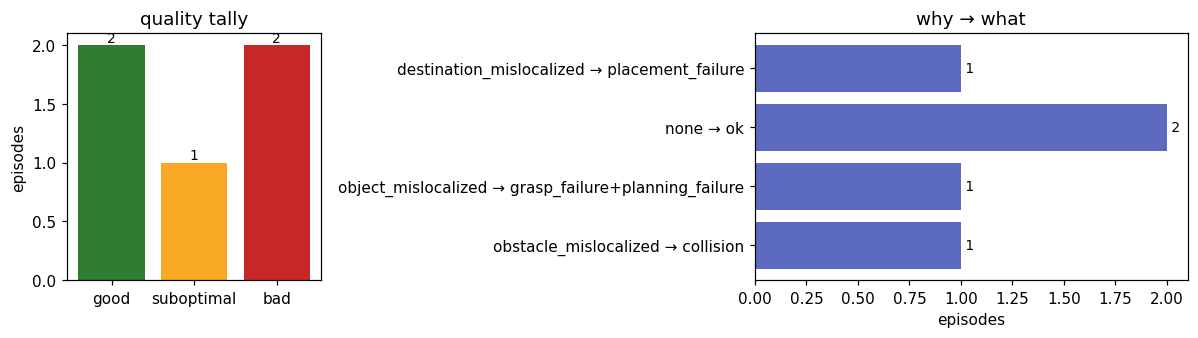

In [4]:
show(render_overview())

## Per-scene twin pairs

Baseline next to its perturbed twin(s); the single controlled edit is the only difference. Curves: task progress and safety (● = contact).

WHAT,ok
WHY,none
quality,good
task_success,✅
object_moved,31.86 cm
place_error,0.09 cm
WHAT,grasp_failure planning_failure
WHY,object_mislocalized target · lateral
quality,bad
task_success,❌
error magnitude,4.50 cm (achieved 4.50 cm)


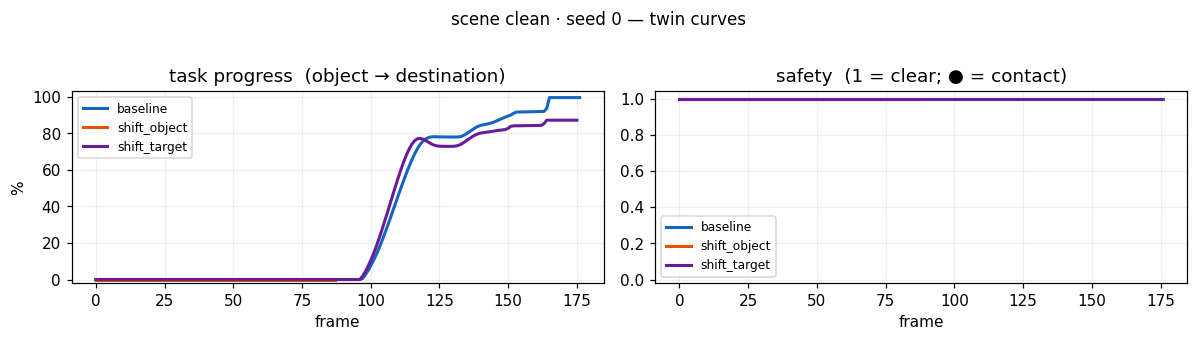

WHAT,ok
WHY,none
quality,good
task_success,✅
object_moved,32.01 cm
place_error,0.21 cm
WHAT,collision
WHY,obstacle_mislocalized obstacle · obstacle_localization_error
quality,suboptimal
task_success,✅
error magnitude,1.59 cm (achieved 1.59 cm)


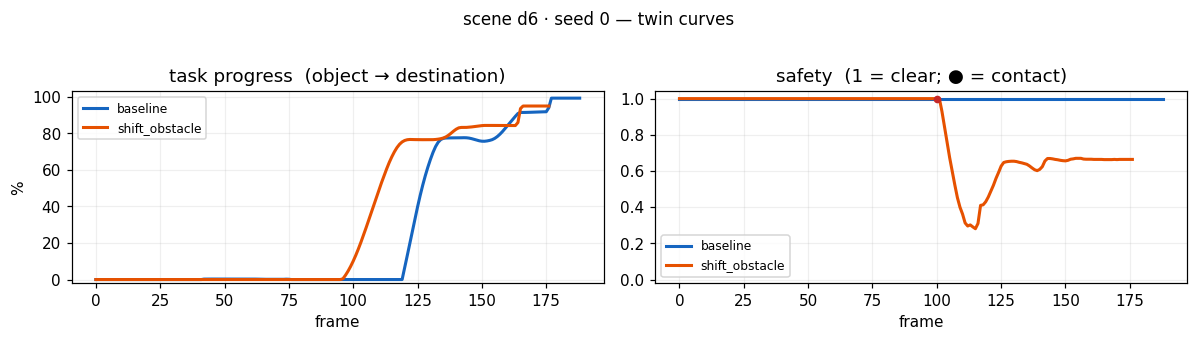

In [5]:
# === Per-scene twin pairs ===
for _scene in SCENES:
    show(render_scene(_scene))


# Reference documentation — Targeted Negative-Data Generation

*Self-contained design + operational reference. This notebook is the single home for the
idea's documentation (the former `TARGETED_NEGATIVE_DATA.md`, `negative_data_brainstorming.md`,
`.claude/negative_data_collection.md`, and `failure_annotation.md` are consolidated here).*

**Status:** working proof-of-concept on one task (`put_mouse_on_pad`); an exploratory
capability proposed as an extension to RoboPRO, not yet a committed benchmark feature. Code
lives under `the `robo_negative` package`.

## Why build it

RoboPRO today perturbs scenes along fixed axes (clutter, language, vision, object) and
**measures** policy success — it never deliberately *induces* a failure, attributes a cause
to it, or pairs it with a matched success. Standard manipulation datasets are likewise blind
to *why* things fail: success-only demos carry no failure information, and rollouts that do
fail leave the cause opaque (recovering it needs human annotation — expensive, often
impossible from video — or a learned classifier, which is circular: it needs the labeled data
we don't have). In simulation we can sidestep the annotation bottleneck: instead of observing
failures and guessing causes, we **induce** failures whose cause we control.

| Consumer | What it needs |
|---|---|
| Safety / collision classifier | Collision events with the colliding object identified and timestamped |
| Failure-mode classifier | Multi-class failure labels with cause |
| Counterfactual / preference learning | (success, failure) pairs differing by one controlled variable |
| Reward / value model | Dense per-step signals (clearance, progress, twin-divergence) with a known fault dose |
| Sensitivity analysis | Failure probability vs. error magnitude |

## Core idea — twin pairs by desynchronization

Every episode has two scene representations:

- **Virtual scene** — what the executor *believes*. For the scripted CuRobo expert this is
  CuRobo's collision world (built by `update_world`) plus task-cached poses read at sub-action
  boundaries (e.g. the grasp pose). For a learned policy, its perception of the observation stream.
- **Actual scene** — what SAPIEN physically simulates.

We run two twins that share the **same plan**:

- **Baseline twin** — virtual == actual. The plan executes as intended → **success**.
- **Perturbed twin** — we apply one small edit to the **actual** scene that the planner
  **never sees** (its virtual scene is unchanged). The plan, built for the virtual world, runs
  in the slightly-different real world → **failure** once the edit crosses tolerance.

Because the twins differ by **exactly one edit we made** (known actor, magnitude, timing), the
failure's cause is **ground truth, not inference**.

### Perturbation types

| Type | Edited actor | Mechanism | Cause label (by construction) |
|---|---|---|---|
| `shift_object` | grasp target | translated **after** the grasp pose is locked → executor reaches a stale pose | `object_mislocalized` |
| `shift_target` | placement destination | translated after the cached placement pose is read | `destination_mislocalized` |
| `shift_obstacle` | a planner-visible obstacle | hidden from the planner, then moved onto the grasp→place corridor → collision by construction | `obstacle_mislocalized` |
| `hide_obstacle` | a non-task obstacle | removed from the planner's world only; physically untouched | `object_undetected` |

Each shift is also **mechanically equivalent to a perception error** at the moment the quantity
was read (a lateral shift along the camera's table-plane axis ≈ a lateral localization error;
along the optical axis ≈ depth misestimation), so shifts are constructed along camera-frame axes
and tagged with a `perceptual_failure_class` ∈ {`depth`, `lateral`, `mixed`}. Classes are assigned
**by construction**: the sampler picks the class, then builds the shift direction along the
matching camera-frame axis; the post-hoc camera-frame decomposition is stored only as a
consistency check. (Post-hoc dominance labeling fails here — the head camera is pitched ~53° down,
so no horizontal shift reads as depth.)

### Three properties that make it a controlled experiment

1. **One controlled variable per episode** — one actor, one edit; commanded *and* achieved
   parameters recorded.
2. **Qualified counterfactual baseline** — a seed qualifies only if *N* baseline runs (default 3,
   in **separate processes** to avoid CuRobo warm-start leakage) all succeed cleanly under the same
   config. Execution is stochastic, so one success is one Bernoulli draw; near the boundary,
   attribution is claimed at the level of success-rate shifts.
3. **Two-sided integrity guard** — after settle, every non-perturbed actor must have moved < 5 mm
   (else discard `scene_disturbed`) **and** the achieved displacement must match the commanded one
   (else `shift_not_achieved`). Labels always use the **achieved** vector; the baseline twin runs
   the identical settle with zero shift.

### Trigger timing is the pin / no-pin knob

The *same* edit δ produces opposite outcomes depending on when it fires relative to the executor's
read:

- `after_grasp_plan` → pose read **before** the teleport → **failure** (acts on a stale belief).
- `immediate` → teleport **before** the read → executor re-reads the shifted pose → **recovery**.

Collecting **both halves** of a perturbation yields a failure/recovery pair that shares an
*identical observation* at the decision point but has *divergent actions and outcomes* — i.e. a
corrective-BC target and a (chosen, rejected) preference pair.

## What it produces — three label layers

The foundational product is the **twin set**: matched success and failure episodes that differ by
one controlled edit. Both are released — it is *not* a failure-only dump. Two pairings fall out:

- **baseline (object at P) vs. failure (object at P+δ)** — differs in the *world*. Clean for a
  cause/collision classifier and counterfactual attribution.
- **failure vs. recovery on the same δ** (deferred vs. immediate trigger) — differs in the *action*
  given a fixed perturbed world. The richer pair for policy improvement.

Each episode carries three label layers:

- **Layer 1 — cause** (`perturbation_type` + commanded/achieved params): ground truth, set by us.
- **Layer 2 — perceptual class** (`perceptual_failure_class`): chosen at construction; deterministic
  given Layer 1; the post-hoc camera-frame decomposition is a consistency check only.
- **Layer 3 — mechanical outcome**, derived from sim signals (success outcomes are first-class):
  `clean_success`, `success_with_collision`, `empty_grasp`, `wrong_place_pose`,
  `collision_with_object`, `plan_aborted`. Object identity and planner visibility are kept as
  *separate* attributes so Layer 3 never leaks Layer 1 (which would inflate downstream classifier
  scores).

## Per-episode data schema (`episode.json`)

Self-describing, versioned (`label_schema_version: 1`). Key fields:

- **Identity / provenance:** `task_name`, `task_config`, `scene_seed`, `executor_type`,
  `executor_checkpoint`, `pair_id`, `pair_role` (`baseline` | `perturbed`).
- **Cause (Layer 1):** `perturbation_type`, `trigger`, `perturbed_actor`, `sampler`
  (`target_class`, `magnitude_cm`, `magnitude_bin_*`, `sign`, `mixed_angle_deg`).
- **Commanded vs. achieved:** `commanded.{magnitude_cm, shift_world, camera_frame}`,
  `achieved.{achieved_world, achieved_magnitude_cm, applied, shift_frame_idx, max_other_actor_move_m}`
  (integrity-guard evidence).
- **Geometry:** `camera_axes` (depth/lateral axes, head-camera forward), `magnitude_bins_cm`,
  `planner_visible_actors`, `progress_entities` (`target`, `destination`).
- **Outcome (Layer 3):** `outcome`, `failure_reason`, `status`.
- **Raw signals:** `signals.{success_flag, plan_success, object_moved_cm, place_error_cm, final_*_p,
  collision_metrics}`, `contact_log` (per-contact: frame, link, object, impulse), `n_frames`, `scene_kind`.

Magnitude bins: `(0.5,1.5)(1.5,2.5)(2.5,3.5)(3.5,5.0)(5.0,8.0)` cm. Sampling uses an **isolated
per-episode RNG** (`np.random.default_rng([...])`), never global `np.random` (scene generation
consumes that stream; sharing it desyncs the twins). Label derivation is pure functions, unit-tested
(`targeted.py`, tests at the bottom of it).

## Per-frame annotation spec (WHAT / WHY / HOW-MUCH / quality)

*Designed direction; the per-frame layer is partly wired (`targeted.annotate` derives WHAT/WHY/quality
today; the continuous per-frame `metrics` and reward/value targets are the remaining build).* The
single per-episode `outcome` is lossy (a precedence ladder that gates on `plan_success` first hides
co-occurring grasp + planning failures) and cause-blind. The redesign emits three aligned channels
per saved frame `t` plus an episode quality grade.

- **WHAT happened** — the symptom, derived from sim: `ok | grasp_failure | placement_failure |
  collision | planning_failure`. Adverse states are spans, not instants (collision over the contact
  span, planning_failure from the abort frame on, etc.), and **can co-occur** — stored as a flag-set,
  not a precedence-ordered single verdict.
- **WHY** — the cause, **known by construction** because we injected it. A step function: `none`
  until `active_from_frame`, then the injected cause to the end (active the whole episode for
  `object_undetected`). Read off the intervention, never inferred:

  | Intervention | WHY |
  |---|---|
  | `shift_object` | `object_mislocalized` (axis ∈ {depth,lateral,vertical,mixed}) |
  | `shift_target` | `destination_mislocalized` |
  | `shift_obstacle` | `obstacle_mislocalized` (believed off-path, truly on-path) |
  | `hide_obstacle` | `object_undetected` (missed detection) |
  | `resize_*` / `swap_*` (future) | `size_misdetected` / `object_misidentified` |

- **HOW MUCH** — exact per-frame numbers (privileged sim measurements used to *construct* targets a
  deployed model predicts from observations alone): `active_error_cm` / `active_error_vector_world`
  (|believed − true| of the faulted entity), `gripper_to_target_cm`, `object_to_destination_cm`,
  `object_height_above_table_cm`, `min_robot_obstacle_clearance_cm`, `contact_impulse_N`, `progress`
  ∈ [0,1], and `twin_divergence_cm` = ‖state_perturbed(t) − state_baseline(t)‖.

**Episode quality** — `good | suboptimal | bad`, a rollup of WHAT + task success: **good** = success
with no adverse frame (incl. a fault fully absorbed); **suboptimal** = success but something happened
(e.g. collision then recovered); **bad** = failed.

**Causal attribution (per twin-pair).** Because the baseline twin has WHY = `none` everywhere, the
perturbed twin's adverse WHAT that the baseline lacks is attributable to the injected cause:
`fault_attributable_what = {adverse WHAT in perturbed} − {adverse WHAT in baseline}`. The twins share
the nominal plan, so their per-frame `metrics` gap is a clean, low-variance learning signal:
`advantage(t) = progress_baseline(t) − progress_perturbed(t)`, with `why_params.magnitude_cm` as a
known dose for calibration.

## Design principles & invariants

The invariants below are load-bearing — breaking one silently biases or mislabels the dataset.

1. **One controlled variable per episode** — one actor, one edit, commanded *and* achieved parameters
   recorded.
2. **Qualified counterfactual baseline** — N baseline runs (default 3, **separate processes** to avoid
   CuRobo warm-start leakage) must all succeed cleanly under the same config; `baseline_trials` /
   `baseline_successes` stamped per episode.
3. **Isolated per-episode RNG** — `np.random.default_rng([...])`, never global `np.random` (scene
   generation consumes that stream; sharing it desyncs the twins).
4. **Two-sided integrity guard** (`runtime.apply_shift`) — after settle, every non-perturbed actor
   moved < 5 mm (`scene_disturbed` else) **and** achieved within tolerance of commanded
   (`shift_not_achieved` else). Labels use the **achieved** vector; baseline runs the identical
   zero-shift settle.
5. **Every attempt is recorded**, including discards/skips with reasons — discards correlate with
   magnitude and clutter, so dropping them silently biases the distribution.
6. **Labels are pure functions, unit-tested.** Layer 1 = cause (set by us), Layer 2 = perceptual class
   (by construction; the camera-frame decomposition is only a consistency check), Layer 3 = mechanical
   outcome (from sim signals). Outcome labels must **not** bake in actor identity or planner visibility.
7. **Class-by-construction sampling** — pick the perceptual class, then build the shift along the
   matching camera-frame axis. Never label by post-hoc dominance.
8. **Blindness is persistent per-episode state**, not a one-shot edit. `TargetedRuntime`
   (the `robo_negative` package) holds an **exclusion set** + a **pose-override map**;
   `Bench_base_task.update_world` consults `is_excluded()` / `override_pose()` on **every** call, so the
   23+ tasks that re-call `update_world` mid-episode cannot silently re-sync the planner.
9. **The edit is timed relative to the executor's read.** `grasp_actor` calls `choose_grasp_pose`
   (reads + locks the live pose) and *then* fires `targeted.notify("after_grasp_plan")`; the teleport
   fires in that notify, so the grasp executes against the stale pose.
10. **Config-driven, not env-var-driven** — a `targeted:` block in `bench_task_config/*.yml`, stamped
    into output paths; env vars only as ad-hoc overrides.

**How the desync is implemented (do not reinvent):** planner blindness is persistent runtime state
(8); the edit is timed relative to the read (9); the trigger is the pin/no-pin knob (`after_grasp_plan`
→ failure, `immediate` → recovery). Defaults in `run_targeted_episode.py` (`TRIGGER_BY_PTYPE`):
`shift_object → after_grasp_plan`, `shift_target`/`shift_obstacle → immediate`.

**Scene-pairing rule (hard):** `shift_object` / `shift_target` run in **clean** configs (no clutter to
confound attribution); `shift_obstacle` / `hide_obstacle` run in **cluttered** configs (they need
obstacles). Enforced in `registry.REQUIRED_SCENE_BY_PTYPE`.

## Executor compatibility

Attribution only requires the qualified counterfactual, so a pretrained policy (e.g. pi05) can be an
executor too — but the label *meaning* changes, and each ptype needs a causal pathway into the
executor's world model. Re-run baseline qualification **per checkpoint**; record `executor_type` and
`executor_checkpoint`.

| Perturbation | Scripted expert (CuRobo) | Pretrained policy (e.g. pi05) |
|---|---|---|
| `shift_object` / `shift_target` | ✅ simulated perception error | ✅ but the policy *sees* the shift — label is **measured robustness** |
| `shift_obstacle` | ✅ (planner must have seen it) | ✅ robustness reading |
| `hide_obstacle` | ✅ | ❌ **no-op**: no planner world model — never emit `missed_detection` |
| `resize_*` (deferred) | ✅ | ⚠️ robustness reading only |

Policies expose no planning events, so triggers become phase-based (e.g. first gripper-close) instead
of `after_grasp_plan`.

## How to run / reproduce

With the **consolidated uv env** active (see the repo `CLAUDE.md`; runs single-process now) and the
bench env exported (`cd customized_robotwin && source set_env.sh && export ROBOTWIN_BENCH_TASK=bench`):

```bash
# Batch orchestrator: per (task, config) group, N baseline runs qualify each seed, then one
# perturbed twin per ptype. Every episode runs in its own subprocess so CuRobo warm-start state
# never leaks between baseline and perturbed twin.
python collect_targeted_data.py \
    --tasks put_mouse_on_pad --seeds 0:40 --target-perturbed 30 --workers 5 --gpus 3,4,5,6,7
```

Useful flags: `--ptypes`, `--n-baseline` (default 3), `--target-perturbed` (default 30), `--out-root`,
`--timeout`, `--gpu`/`--gpus`, `--workers`. Recorded episodes resume from cache. A single episode runs
directly via `run_targeted_episode.py` (`--role`, `--ptype`, `--params-json`, `--out-dir`, …).

This demo is regenerated by the **Collect** cell at the top of this notebook (which folds in the former
`make_negative_data_demo.py`); each episode is an isolated `run_targeted_episode.py` subprocess. The
standalone animated-chart HTML gallery is still available via `visualize_negative_data.py`. **This notebook
supersedes the old `demo_report.md`.**

## Scope, limitations & non-goals

**Honest scope.** The scripted expert re-reads ground truth at sub-action boundaries, so a perturbation
desyncs exactly **one locked quantity at one decision point** — it models a bad detection at grasp/place
time, **not** a persistently biased sensor. No claim of closed-loop trajectory fidelity: a policy that
re-perceives every frame would partially correct and fail differently. `shift_target` against a static
destination largely re-measures the success-check epsilon (the genuinely stochastic boundary lives in
`shift_object`). Coverage is small (one audited task today). `resize_*` is blocked by SAPIEN 3.0.0b1
(can't rescale collision shapes in place → destroy + rebuild + re-register).

**Non-goals (do not build without being asked):** closed-loop perception corruption (rendering objects
where the policy believes them); re-planning after perturbation (tests recovery, not blindness);
`swap_target_id` / `phantom_obstacle` / `rotate_target` (backlog until the shift family is validated);
`resize_*` (schedule only if size-error classes are explicitly needed).

## Roadmap (execution plan)

- **Phase 0 — PoC (done):** one task, shift family, ~30 perturbed episodes + qualified baselines;
  decouple collision metrics from planner blindness + record `planner_visible_actors`; `targeted`
  label package; perturbation runtime (sampler, triggers, exclusion set + pose-override, integrity
  guard); per-contact collision log; HDF5 annotation writer; paired collector.
- **Phase 1 — Production pipeline:** budget = N attempts; baseline-qualification pass then perturbed
  pass over qualifying seeds; incremental index; `targeted:` config block.
- **Phase 2 — Coverage:** base-class default spec (tasks following the `target_obj`/`des_obj`
  convention get `shift_object`/`shift_target` for free); **automated desync audit** as the admission
  test per (task, ptype); roll out to 8–10 audited tasks; `hide_obstacle` via the exclusion set;
  swept-volume corridor refinement; `resize_target` (cost noted above).
- **Phase 3 — Validation (science gate):** artifact audit around deferred shifts; classifier sanity
  check (obs → `perceptual_failure_class`, ablated with the masking convention to prove it isn't a
  teleport detector); label-noise human review; dataset card v0.
- **Phase 4 — Scale:** sweep configs per task × ptype × class quota × magnitude bin; SLURM wrappers;
  balanced per-class targets; dataset card regenerated per release.

## Code map

| Concern | Location |
|---|---|
| Per-episode desync state, triggers, integrity guard | the `robo_negative` package |
| Stratified, class-by-construction sampling (pure) | the `robo_negative` package |
| Three-layer label derivation + WHAT/WHY/quality annotation (pure, tested) | the `robo_negative` package |
| Offline per-frame metrics (progress, safety) | the `robo_negative` package |
| Supported-task registry + scene-pairing rule | the `robo_negative` package |
| HDF5 label annotation | the `robo_negative` package |
| Planner hooks (`update_world`, `grasp_actor` notify) | `benchmark/bench_envs/_bench_base_task.py` |
| Per-episode subprocess runner | `run_targeted_episode.py` |
| Batch orchestrator (baseline qualification + twins) | `collect_targeted_data.py` |
| Demo collection (this dataset) | the **Collect** cell in this notebook (spawns `run_targeted_episode.py` per episode) |
| Standalone HTML gallery (alternative viewer) | `visualize_negative_data.py` |
| **This notebook** | the single home for the idea's documentation + showcase |